# PHẦN 1: PHÁT BIỂU MỤC TIÊU VÀ GIẢ THUYẾT

**1. Vấn đề:**
Bài toán đặt ra là xây dựng một hệ thống nhận diện biển số xe (License Plate Recognition) từ ảnh chụp thực tế. Dữ liệu đầu vào là các bức ảnh chụp phương tiện giao thông ở nhiều góc độ và điều kiện ánh sáng khác nhau. Mục tiêu là trích xuất và nhận dạng chính xác các ký tự trên biển số.

**2. Giả thuyết:**
Chúng tôi dự đoán rằng việc áp dụng kết hợp **Toán tử hình thái học (Morphological Operations)** để tăng độ tương phản và **Nhị phân hóa cục bộ (Adaptive Thresholding)** sẽ mang lại hiệu quả tách nền và làm nổi bật ký tự tốt hơn đáng kể so với phương pháp nhị phân hóa toàn cục (Global Thresholding) truyền thống. Lý do là vì ảnh chụp ngoài trời thường chịu ảnh hưởng của ánh sáng không đồng đều và bóng râm, khiến Global Thresholding dễ bị mất nét chữ.

**3. Tiêu chí thành công:**
Hệ thống có khả năng nhận dạng đúng các ký tự trên biển số. Tiêu chí đánh giá định lượng là độ chính xác (Accuracy) của việc nhận dạng đúng toàn bộ biển số trên tập dữ liệu Validation.


 Import thư viện

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Cấu hình matplotlib để hiển thị ảnh to, rõ ràng hơn trong Notebook
plt.rcParams['figure.figsize'] = (10, 8)

### Bước 1: Tự động quét và đọc ảnh gốc từ thư mục Validation (val)
Hệ thống sẽ tự động tìm kiếm tất cả các tệp ảnh nằm trong thư mục `data/raw_data/images/val/`. 
Sau đó, bốc ngẫu nhiên một ảnh đầu vào (Raw Data) để làm mẫu thử nghiệm qua các bước xử lý ảnh phía sau.

Đã tìm thấy 2290 ảnh. Đang lấy file test: carlong_0004.png


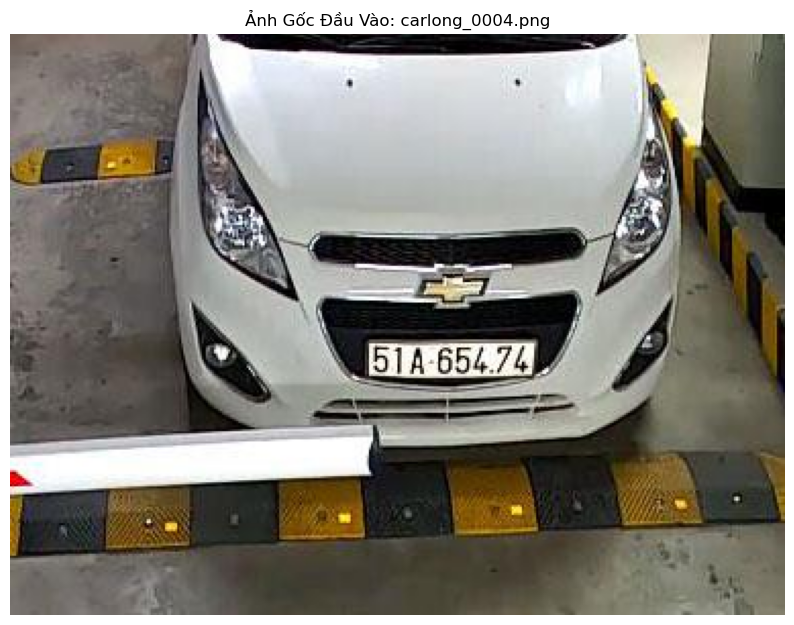

In [8]:
import os
import glob
import sys
from pathlib import Path

# =====================================================================
# HỆ THỐNG ĐƯỜNG DẪN THÔNG MINH (HỖ TRỢ CẢ GOOGLE COLAB & MÁY CÁ NHÂN)
# =====================================================================

# Kiểm tra xem có đang chạy trên Google Colab không
if 'google.colab' in sys.modules:
    print("🖥️ Môi trường: Google Colab")
    from google.colab import drive
    
    # Tự động kết nối với Google Drive
    if not os.path.exists('/content/drive'):
        print("Đang kết nối với Google Drive...")
        drive.mount('/content/drive')
    
    # ⚠️ QUAN TRỌNG: Sửa đường dẫn này trỏ tới đúng thư mục bạn đã upload trên Drive
    # Ví dụ: Nếu bạn upload thư mục 'nh-n-bi-n-s-xe' vào thư mục gốc của Drive
    project_root = Path('/content/drive/MyDrive/nh-n-bi-n-s-xe')
    
    if not project_root.exists():
        print(f"❌ KHÔNG TÌM THẤY DỰ ÁN TẠI: {project_root}")
        print("👉 Hướng dẫn: Bạn cần upload thư mục 'nh-n-bi-n-s-xe' lên Google Drive của bạn trước khi chạy.")
else:
    print("💻 Môi trường: Máy tính cá nhân (Local PC)")
    # Tự động dò tìm thư mục gốc chứa file Redme.md
    current_dir = Path.cwd()
    project_root = current_dir
    while not (project_root / "Redme.md").exists() and project_root.parent != project_root:
        project_root = project_root.parent

val_images_dir = project_root / "data" / "raw data" / "images" / "val"
output_dir = project_root / "data" / "data_processing" / "tien_xu_ly"

if not val_images_dir.exists():
    print(f"❌ LỖI: Không tìm thấy thư mục ảnh tại: {val_images_dir}")
else:
    # Quét tất cả các file có đuôi ảnh (.jpg, .jpeg, .png) trong thư mục val
    image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    image_files = []
    for ext in image_extensions:
        search_pattern = (val_images_dir / ext).as_posix()
        image_files.extend(glob.glob(search_pattern))

    if len(image_files) == 0:
        print(f"❌ LỖI: Không tìm thấy ảnh nào trong thư mục: '{val_images_dir}'")
    else:
        # Lấy ảnh đầu tiên trong danh sách (Index 0). Bạn có thể đổi sang số khác (1, 2, 3...) để test ảnh khác.
        img_path = image_files[0] 
        print(f"✅ Đã tìm thấy {len(image_files)} ảnh. Đang lấy file test: {os.path.basename(img_path)}")
        
        # Đọc ảnh bằng OpenCV
        import cv2
        import matplotlib.pyplot as plt
        img = cv2.imread(img_path)
        
        # Chuyển đổi hệ màu BGR sang RGB để hiển thị đúng màu trên Jupyter Notebook
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Hiển thị ảnh gốc
        plt.imshow(img_rgb)
        plt.title(f"Ảnh Gốc Đầu Vào: {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()


### Bước 2: Chuyển đổi không gian màu sang ảnh xám qua kênh V (HSV)
Thay vì sử dụng phương pháp chuyển đổi ảnh xám Grayscale truyền thống từ hệ màu RGB, đồ án lựa chọn chuyển ảnh sang không gian màu **HSV** và chỉ trích xuất **kênh V (Value - Cường độ sáng)**. 
Phương pháp này giúp ảnh có độ độc lập cao hơn đối với sự thay đổi của các yếu tố ánh sáng môi trường bên ngoài (nắng, bóng râm, chói đèn).

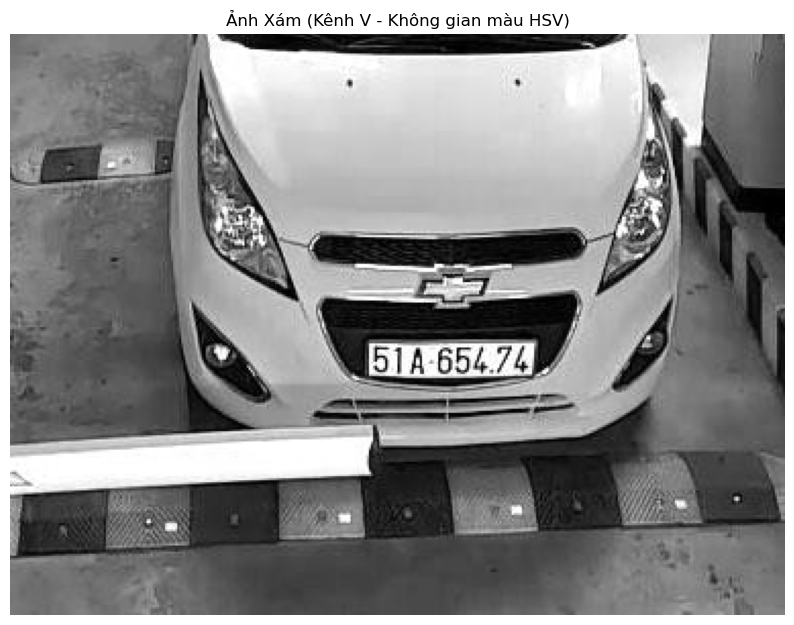

In [9]:
# Chuyển đổi ảnh gốc sang hệ màu HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Lấy kênh V (Index số 2 trong hệ HSV) làm ảnh xám tiền xử lý
img_gray = img_hsv[:, :, 2] 

# Hiển thị kết quả ảnh xám kênh V
plt.imshow(img_gray, cmap='gray')
plt.title('Ảnh Xám (Kênh V - Không gian màu HSV)')
plt.axis('off')
plt.show()

### Bước 3: Tăng cường độ tương phản cục bộ bằng Hình thái học (Morphological)
Để làm nổi bật các góc cạnh của biển số và các kí tự chữ/số so với vỏ xe, ta áp dụng toán tử hình thái học với cấu trúc phần tử chữ nhật (Kernel) kích thước $13 \times 13$:
- **Top Hat**: Giúp giữ lại và làm nổi bật các chi tiết sáng trên nền tối.
- **Black Hat**: Giúp giữ lại và làm nổi bật các chi tiết tối trên nền sáng.

Công thức áp dụng tăng tương phản: `Ảnh kết quả = Ảnh xám gốc + Top Hat - Black Hat`

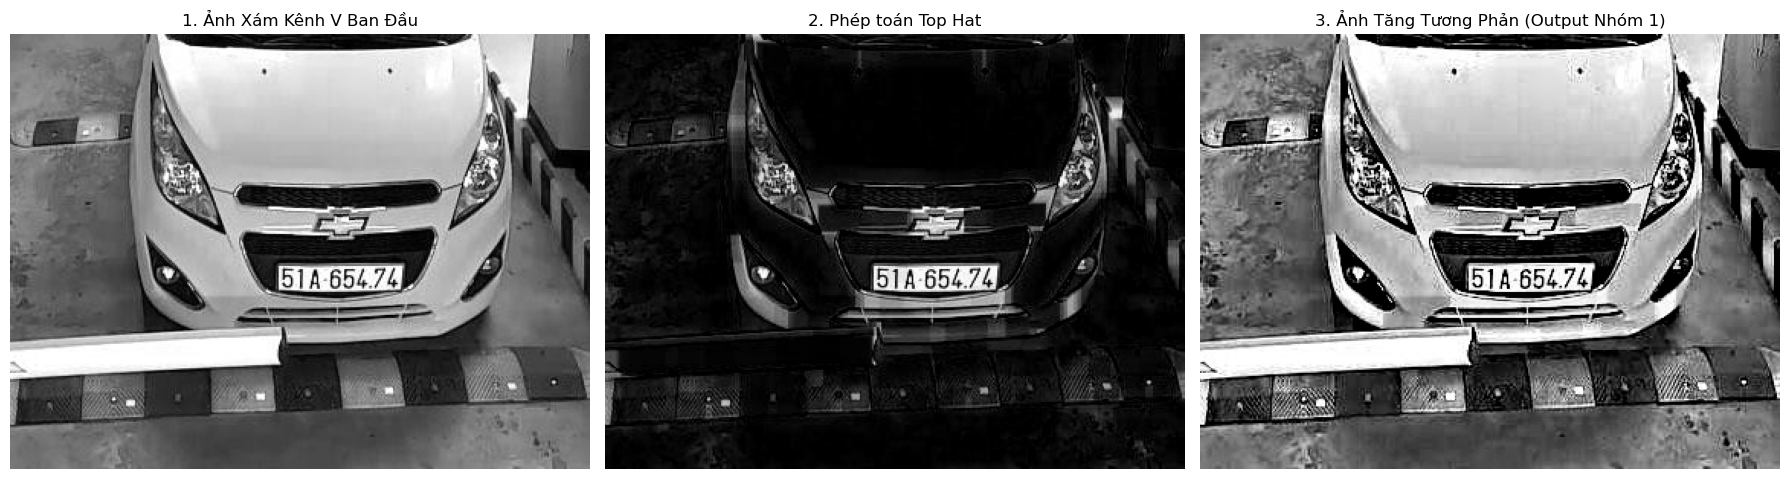

In [10]:
# Khởi tạo ma trận phần tử cấu trúc hình chữ nhật kích thước 13x13 phù hợp kích thước biển số
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))

# Áp dụng bộ lọc Top Hat và Black Hat
top_hat = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)
black_hat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)

# Tính toán tăng độ tương phản theo công thức trong đồ án
img_contrast = cv2.add(img_gray, top_hat)
img_contrast = cv2.subtract(img_contrast, black_hat)

# Vẽ biểu đồ so sánh trực quan các bước biến đổi để báo cáo với thầy
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_gray, cmap='gray')
axs[0].set_title('1. Ảnh Xám Kênh V Ban Đầu')
axs[0].axis('off')

axs[1].imshow(top_hat, cmap='gray')
axs[1].set_title('2. Phép toán Top Hat')
axs[1].axis('off')

axs[2].imshow(img_contrast, cmap='gray')
axs[2].set_title('3. Ảnh Tăng Tương Phản (Output Nhóm 1)')
axs[2].axis('off')

plt.tight_layout()
plt.show()

### Bước 4: Xử lý tăng tương phản hàng loạt và lưu kết quả
Để đảm bảo thuật toán hoạt động ổn định trên nhiều điều kiện ánh sáng và góc chụp khác nhau, ta tiến hành quét toàn bộ tập dữ liệu trong thư mục `val`. 
Kết quả sau khi tăng tương phản (`img_contrast`) sẽ được lưu vào thư mục `data/data_processing/` để làm đầu vào cho các bước khử nhiễu của Nhóm 2.

In [ ]:
# Tạo thư mục đích nếu chưa tồn tại
output_dir = project_root / "data" / "data_processing" / "tien_xu_ly"
os.makedirs(output_dir, exist_ok=True)

print(f" Bắt đầu xử lý hàng loạt {len(image_files)} ảnh...")

count = 0
# Định nghĩa lại kernel 13x13 cho chắc chắn
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 13))

for path in image_files:
    # Đọc ảnh
    img_raw = cv2.imread(path)
    if img_raw is None:
        continue
        
    # 1. Chuyển HSV lấy kênh V
    img_hsv_batch = cv2.cvtColor(img_raw, cv2.COLOR_BGR2HSV)
    img_gray_batch = img_hsv_batch[:, :, 2]
    
    # 2. Thực hiện toán tử Top-Hat và Black-Hat
    top_hat_batch = cv2.morphologyEx(img_gray_batch, cv2.MORPH_TOPHAT, kernel)
    black_hat_batch = cv2.morphologyEx(img_gray_batch, cv2.MORPH_BLACKHAT, kernel)
    
    # 3. Tính toán tăng tương phản
    img_contrast_batch = cv2.add(img_gray_batch, top_hat_batch)
    img_contrast_batch = cv2.subtract(img_contrast_batch, black_hat_batch)
    
    # 4. Lưu ảnh vào thư mục data/data_processing/ giữ nguyên tên gốc
    file_name = os.path.basename(path)
    output_path = os.path.join(output_dir, file_name)
    cv2.imwrite(output_path, img_contrast_batch)
    
    count += 1

print(f" Đã xử lý thành công {count}/{len(image_files)} ảnh!")
print(f" Toàn bộ ảnh đã được lưu vào thư mục: '{output_dir}'")

 Bắt đầu xử lý hàng loạt 2290 ảnh...
 Đã xử lý thành công 2290/2290 ảnh!
 Toàn bộ ảnh đã được lưu vào thư mục: 'E:\Nhom_A\data\data_processing'


### BƯỚC KHẢO SÁT THAM SỐ (YÊU CẦU BẮT BUỘC)
**Khảo sát tham số kích thước Kernel trong Toán tử hình thái học**

Tham số quan trọng trong bước tăng cường độ tương phản là **kích thước của phần tử cấu trúc (kernel size)**. 
Nếu kernel quá nhỏ, nó sẽ không bao phủ hết nét chữ, không tạo ra được độ tương phản đủ mạnh. Nếu kernel quá lớn, nó có thể lấy cả những chi tiết nhiễu không mong muốn xung quanh biển số.
Dưới đây, chúng tôi chạy thử nghiệm với 3 giá trị kernel khác nhau: **(5, 5)**, **(13, 13)**, và **(21, 21)** để đánh giá tác động của tham số này.


In [ ]:
# KHẢO SÁT 3 KÍCH THƯỚC KERNEL KHÁC NHAU
kernel_sizes = [(5, 5), (13, 13), (21, 21)]
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

for i, k_size in enumerate(kernel_sizes):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, k_size)
    top_hat = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)
    black_hat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)
    img_contrast_test = cv2.add(cv2.subtract(img_gray, top_hat), black_hat)
    
    axs[i].imshow(img_contrast_test, cmap='gray')
    axs[i].set_title(f'Kernel Size: {k_size}')
    axs[i].axis('off')

plt.suptitle("So sánh ảnh hưởng của kích thước Kernel đến độ tương phản", fontsize=16)
plt.tight_layout()
plt.show()

# Nhận xét:
print("Nhận xét:")
print("- Kernel (5,5): Kích thước quá nhỏ, độ tương phản tăng không đáng kể, các nét chữ chưa thực sự nổi bật.")
print("- Kernel (13,13): Phù hợp với kích thước trung bình của ký tự trên biển số trong tập dữ liệu, làm nổi bật rõ nét chữ.")
print("- Kernel (21,21): Kernel quá lớn bắt đầu làm nhiễu nền xung quanh chữ, làm ảnh hưởng đến bước nhị phân hóa sau này.")
print("=> Quyết định chọn Kernel (13, 13) cho pipeline.")
